In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

train = pd.read_parquet("../data/train.parquet")
test = pd.read_parquet("../data/test.parquet")

for df in (train, test):
    df["rate_differential"] = df["sa_repo_rate"] - df["us_fed_funds"]

key_cols = [
    "usd_zar", "gold_usd_per_oz", "platinum_usd_per_oz",
    "sa_5y_cds_bp", "vix", "broad_usd_index", "rate_differential",
]

## USDZAR series — what we're forecasting

The raw USDZAR exchange rate over the full available history, and zoomed
into the 2021–2025 forecast period used for this task.

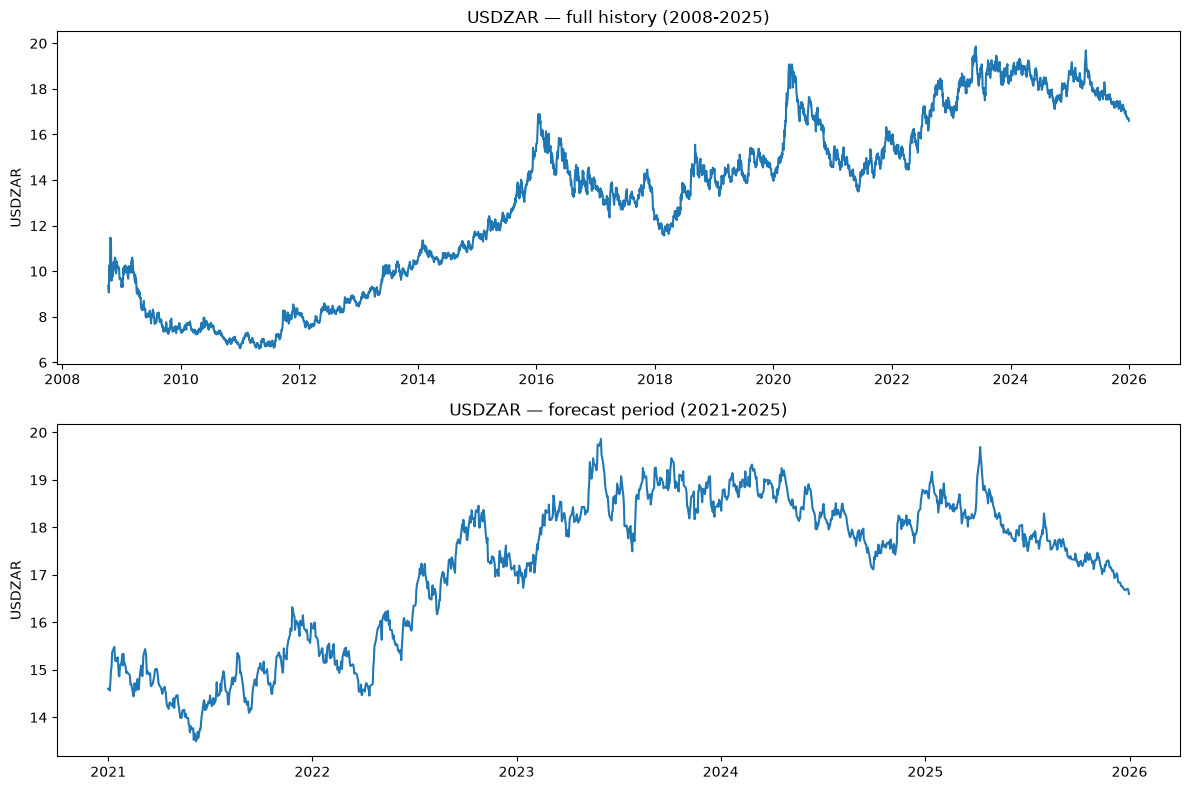

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=False)

# Full history
full = pd.concat([train, test]).sort_values("date")
axes[0].plot(full["date"], full["usd_zar"], color="tab:blue")
axes[0].set_title("USDZAR — full history (2008-2025)")
axes[0].set_ylabel("USDZAR")

# Zoomed to forecast period
axes[1].plot(test["date"], test["usd_zar"], color="tab:blue")
axes[1].set_title("USDZAR — forecast period (2021-2025)")
axes[1].set_ylabel("USDZAR")

plt.tight_layout()
plt.show()

## Correlation matrix — training period (2008–2020)

Pairwise correlations between USDZAR and candidate predictors over the longer
historical training window. Used to identify which macro/commodity variables
move most closely with the Rand before the forecast period begins.

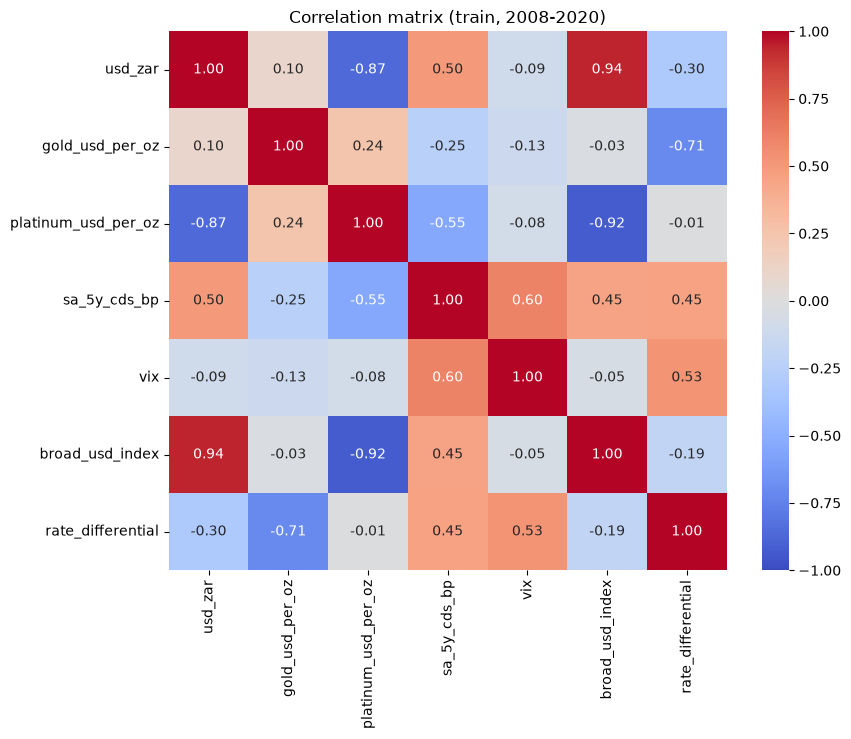

In [2]:
corr = train[key_cols].corr()
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Correlation matrix (train, 2008-2020)")
plt.show()

## Correlation matrix — forecast period (2021–2025)

Same predictors, but measured only over the out-of-sample forecast window.
Comparing this to the training-period matrix shows whether these relationships
have stayed stable or shifted between the two eras.

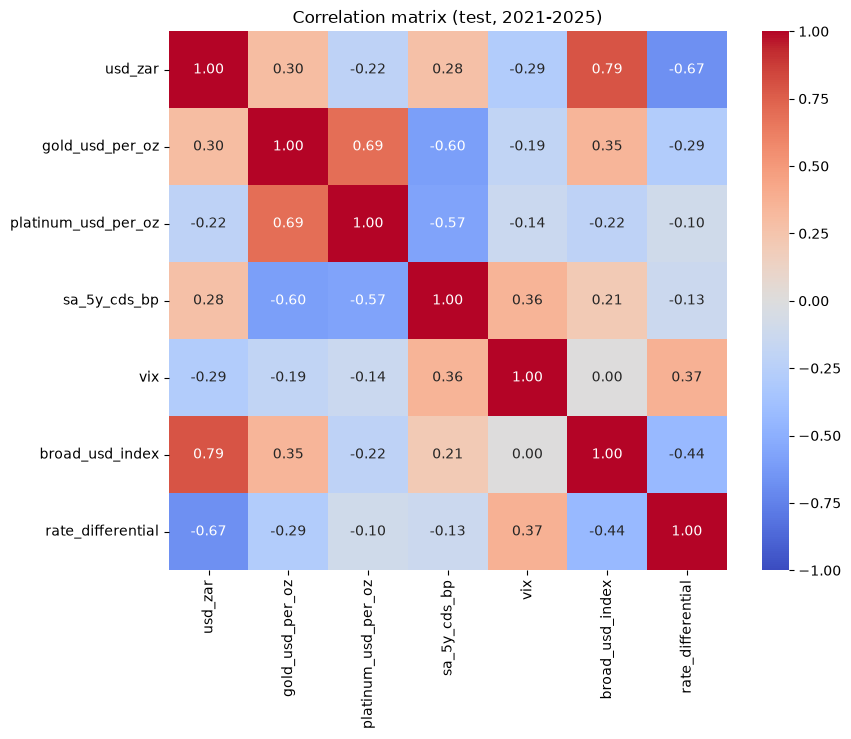

In [3]:
corr = test[key_cols].corr()
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Correlation matrix (test, 2021-2025)")
plt.show()

## Pair plot — training period (2008–2020)

Scatter relationships and distributions for USDZAR and each predictor,
covering the 2008 financial crisis through 2020. Useful for spotting
non-linear relationships that a simple correlation coefficient would miss.

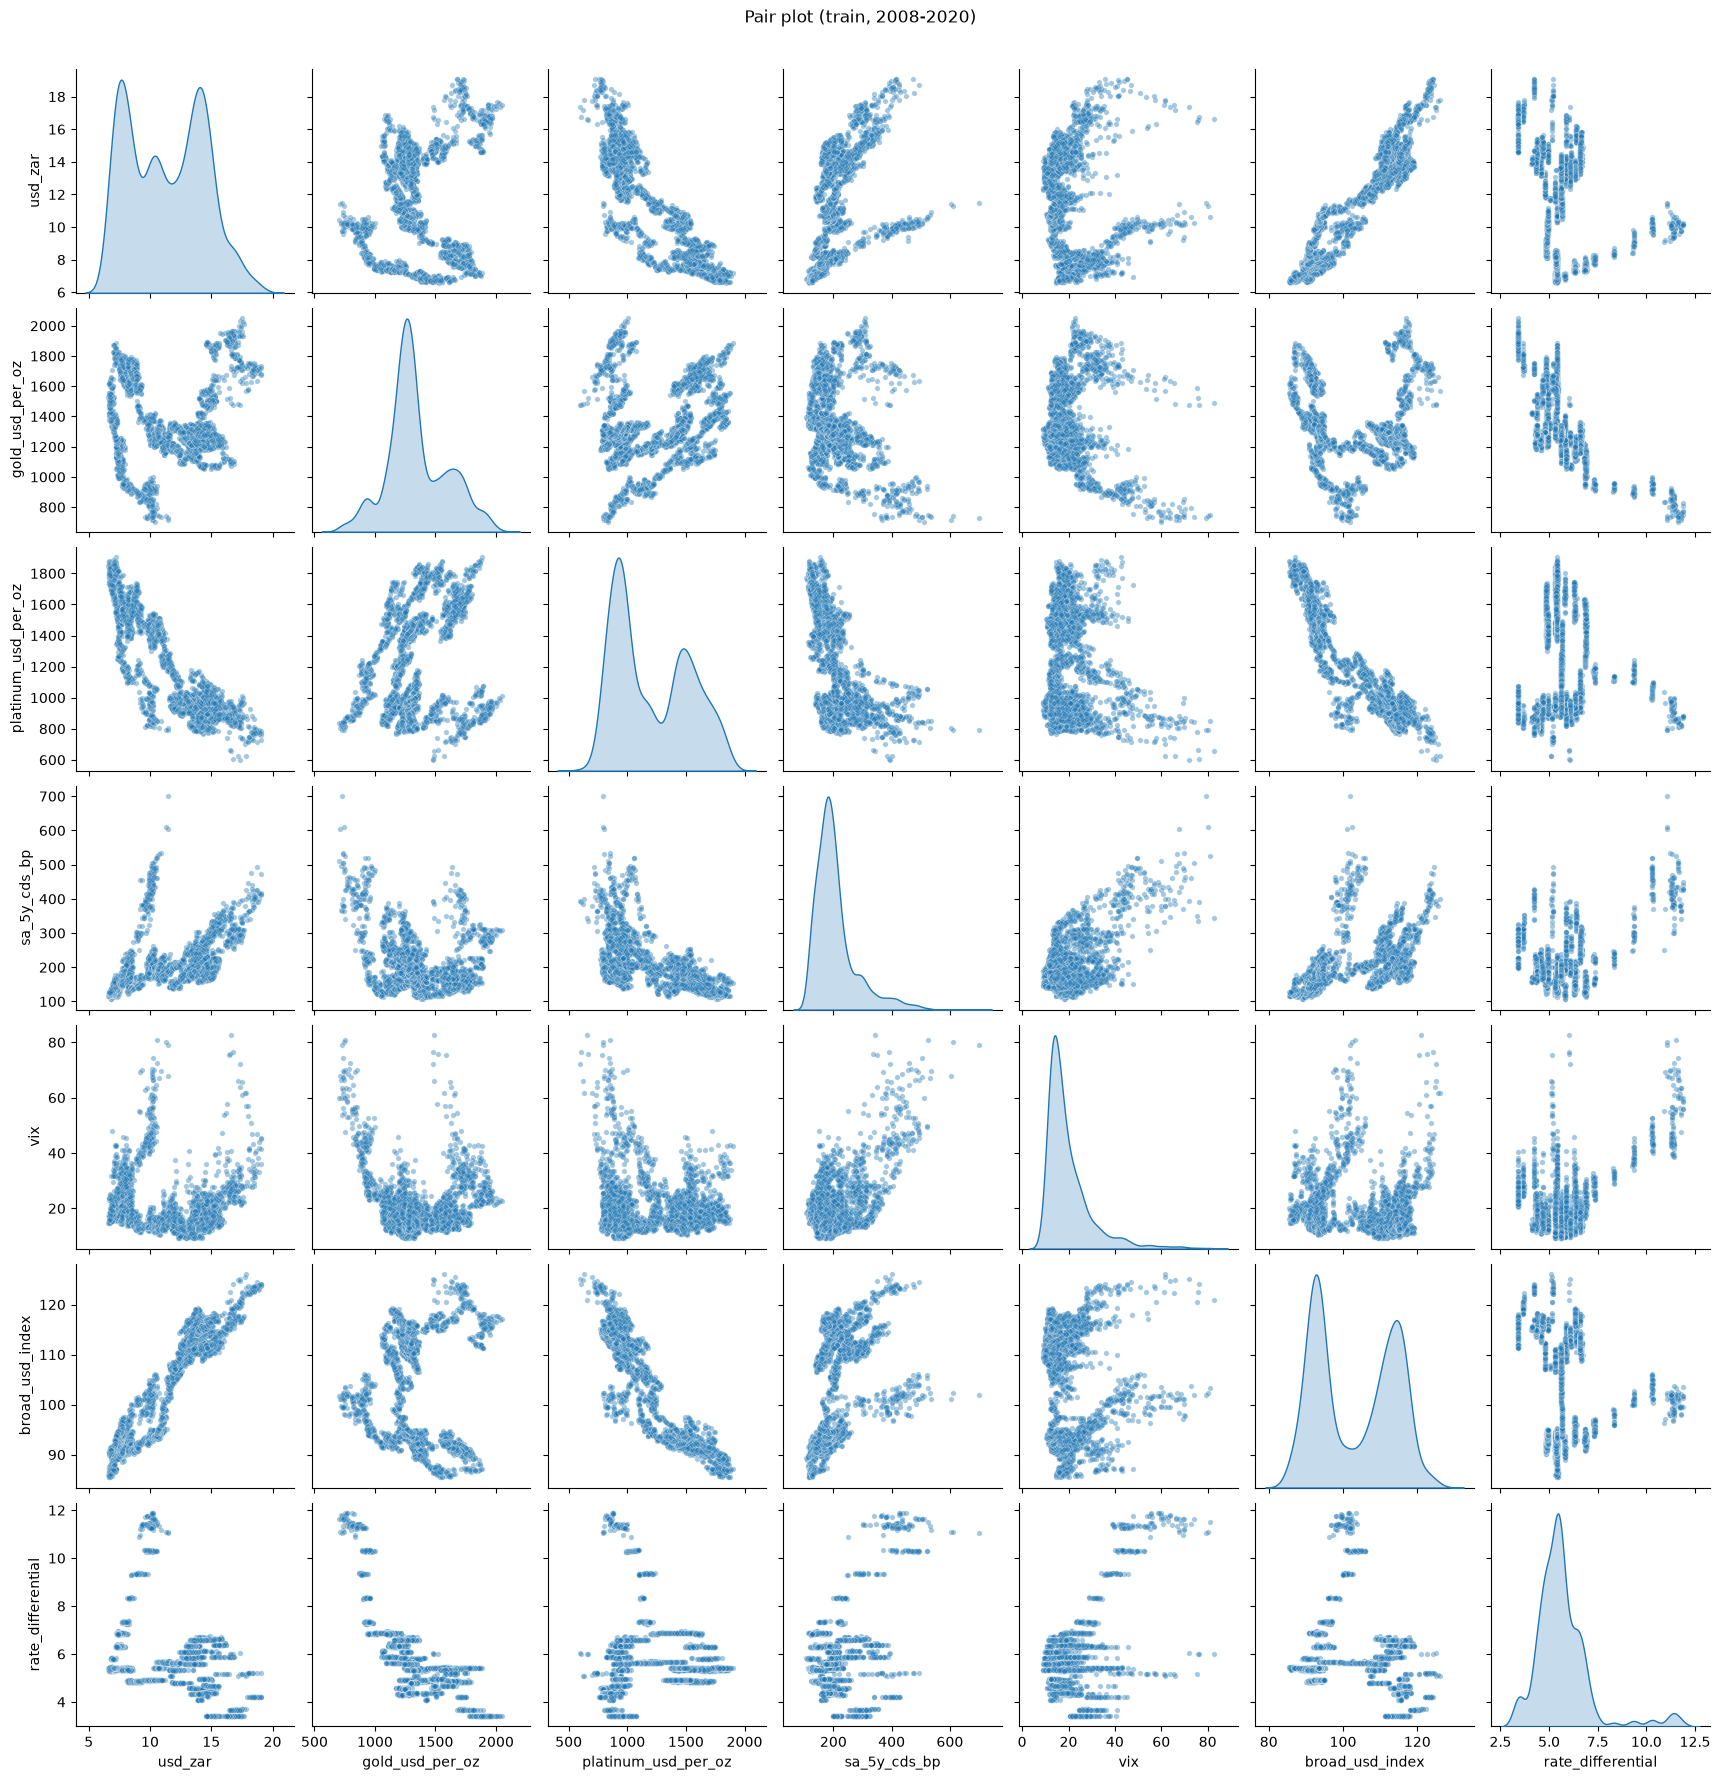

In [4]:
sns.pairplot(train[key_cols].dropna(), diag_kind="kde", plot_kws={"alpha": 0.4, "s": 15})
plt.suptitle("Pair plot (train, 2008-2020)", y=1.02)
plt.show()

## Pair plot — forecast period (2021–2025)

Same view restricted to the forecast window, for direct comparison against
the training-period relationships above.

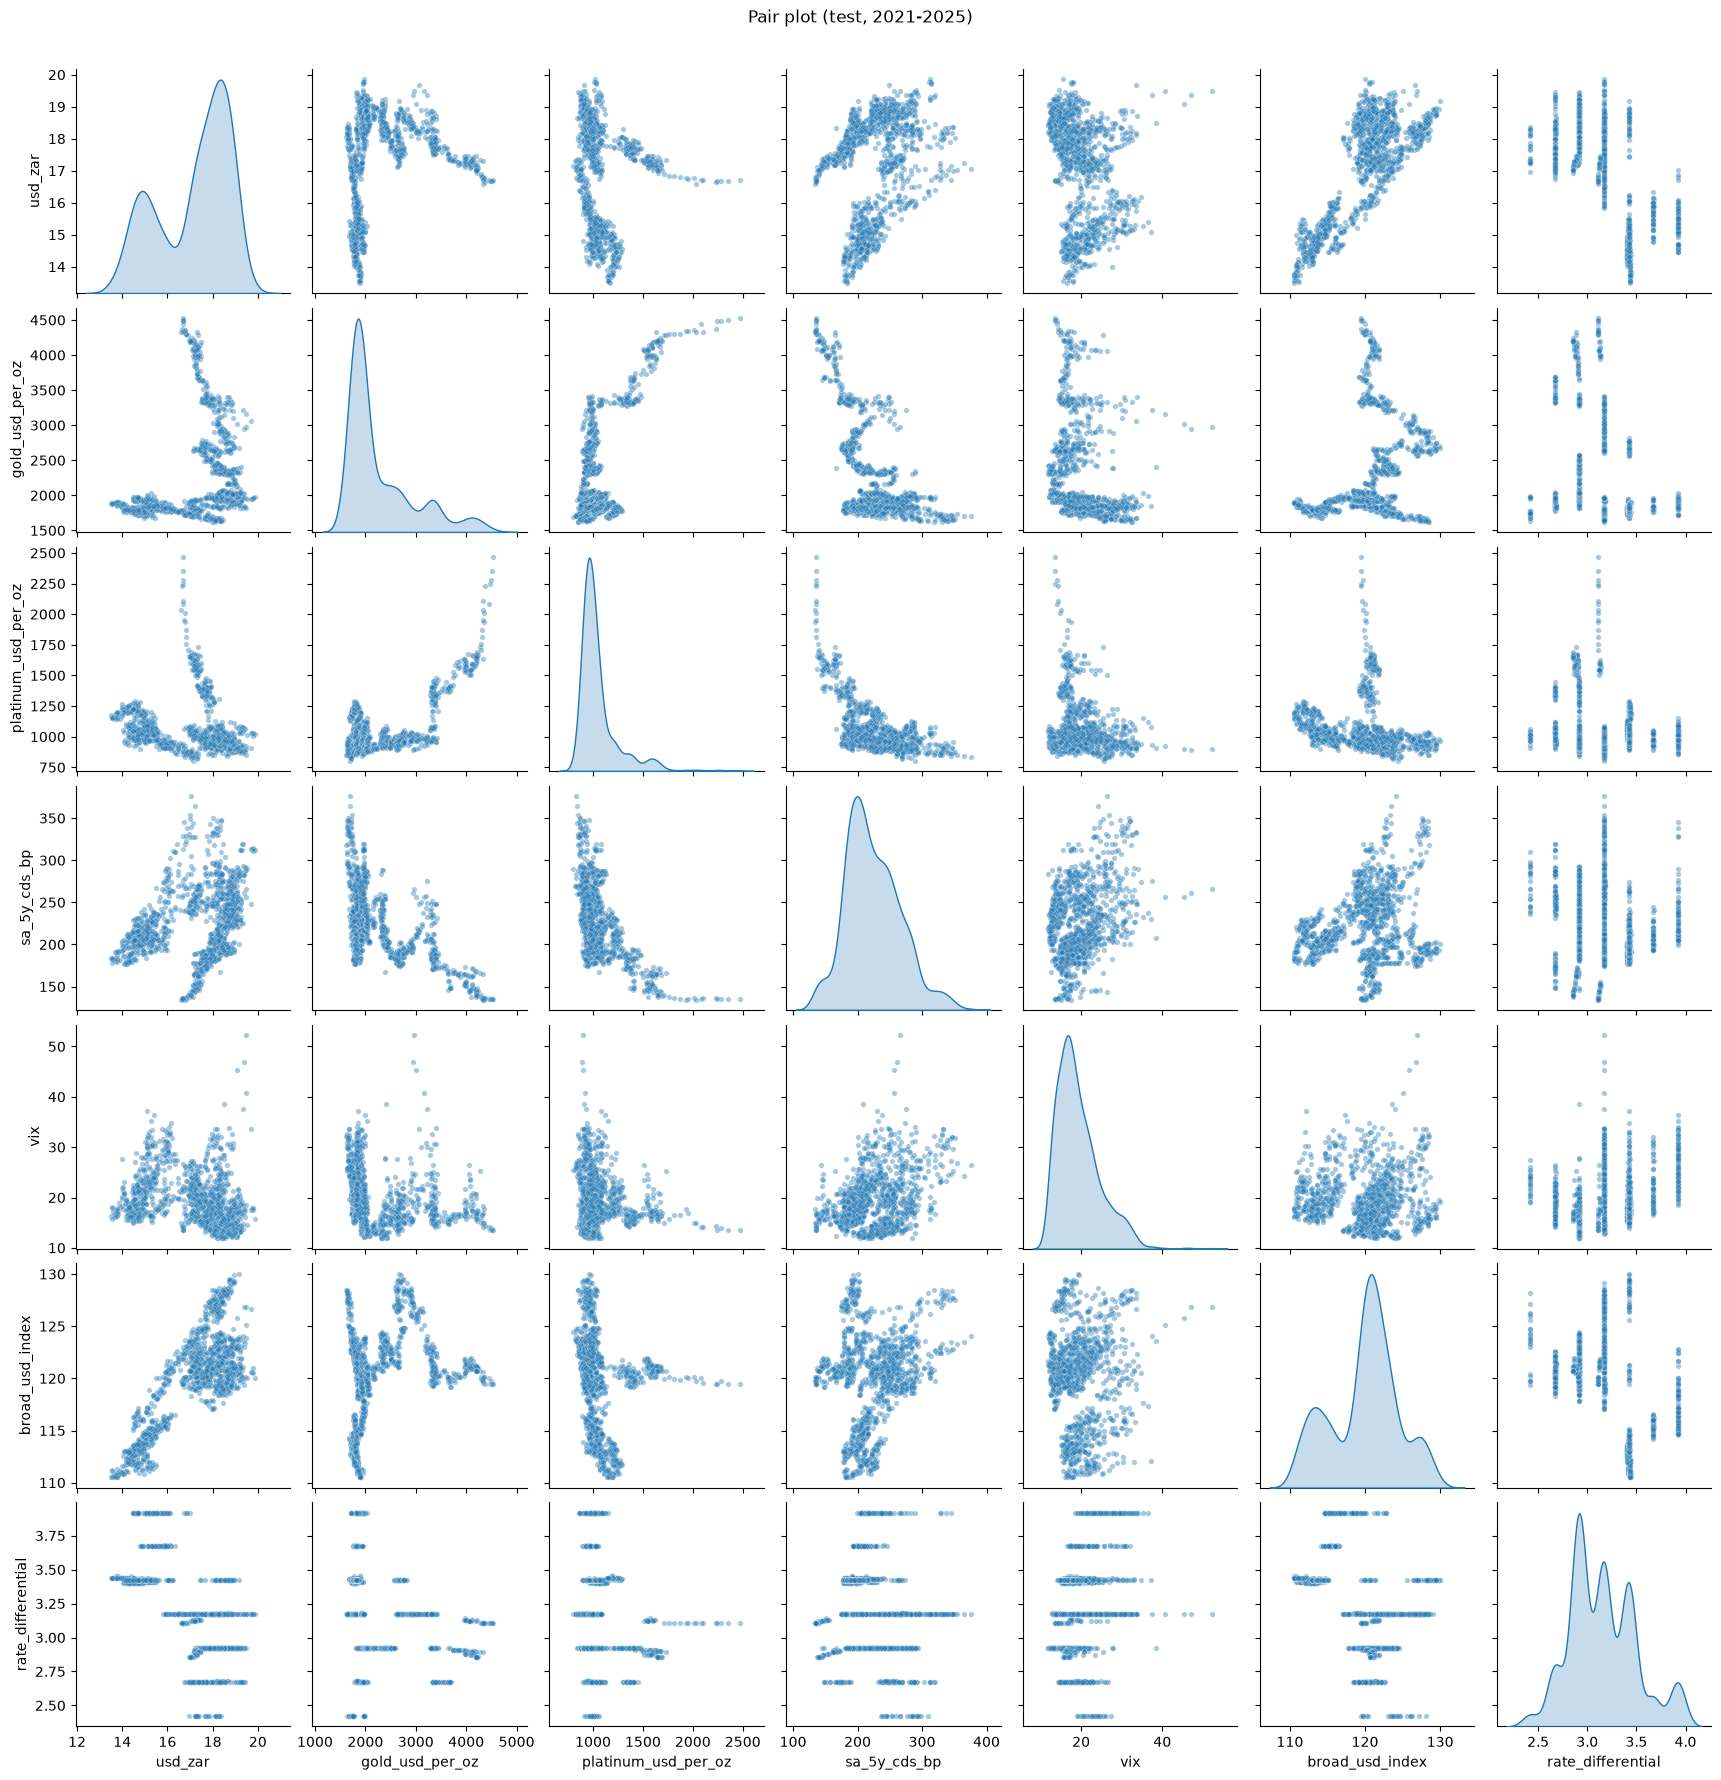

In [5]:
sns.pairplot(test[key_cols].dropna(), diag_kind="kde", plot_kws={"alpha": 0.4, "s": 15})
plt.suptitle("Pair plot (test, 2021-2025)", y=1.02)
plt.show()

## USDZAR vs. each predictor over time — training period (2008–2020)

Direct time series overlay of USDZAR against each candidate predictor,
showing how closely (or loosely) they tracked each other historically.

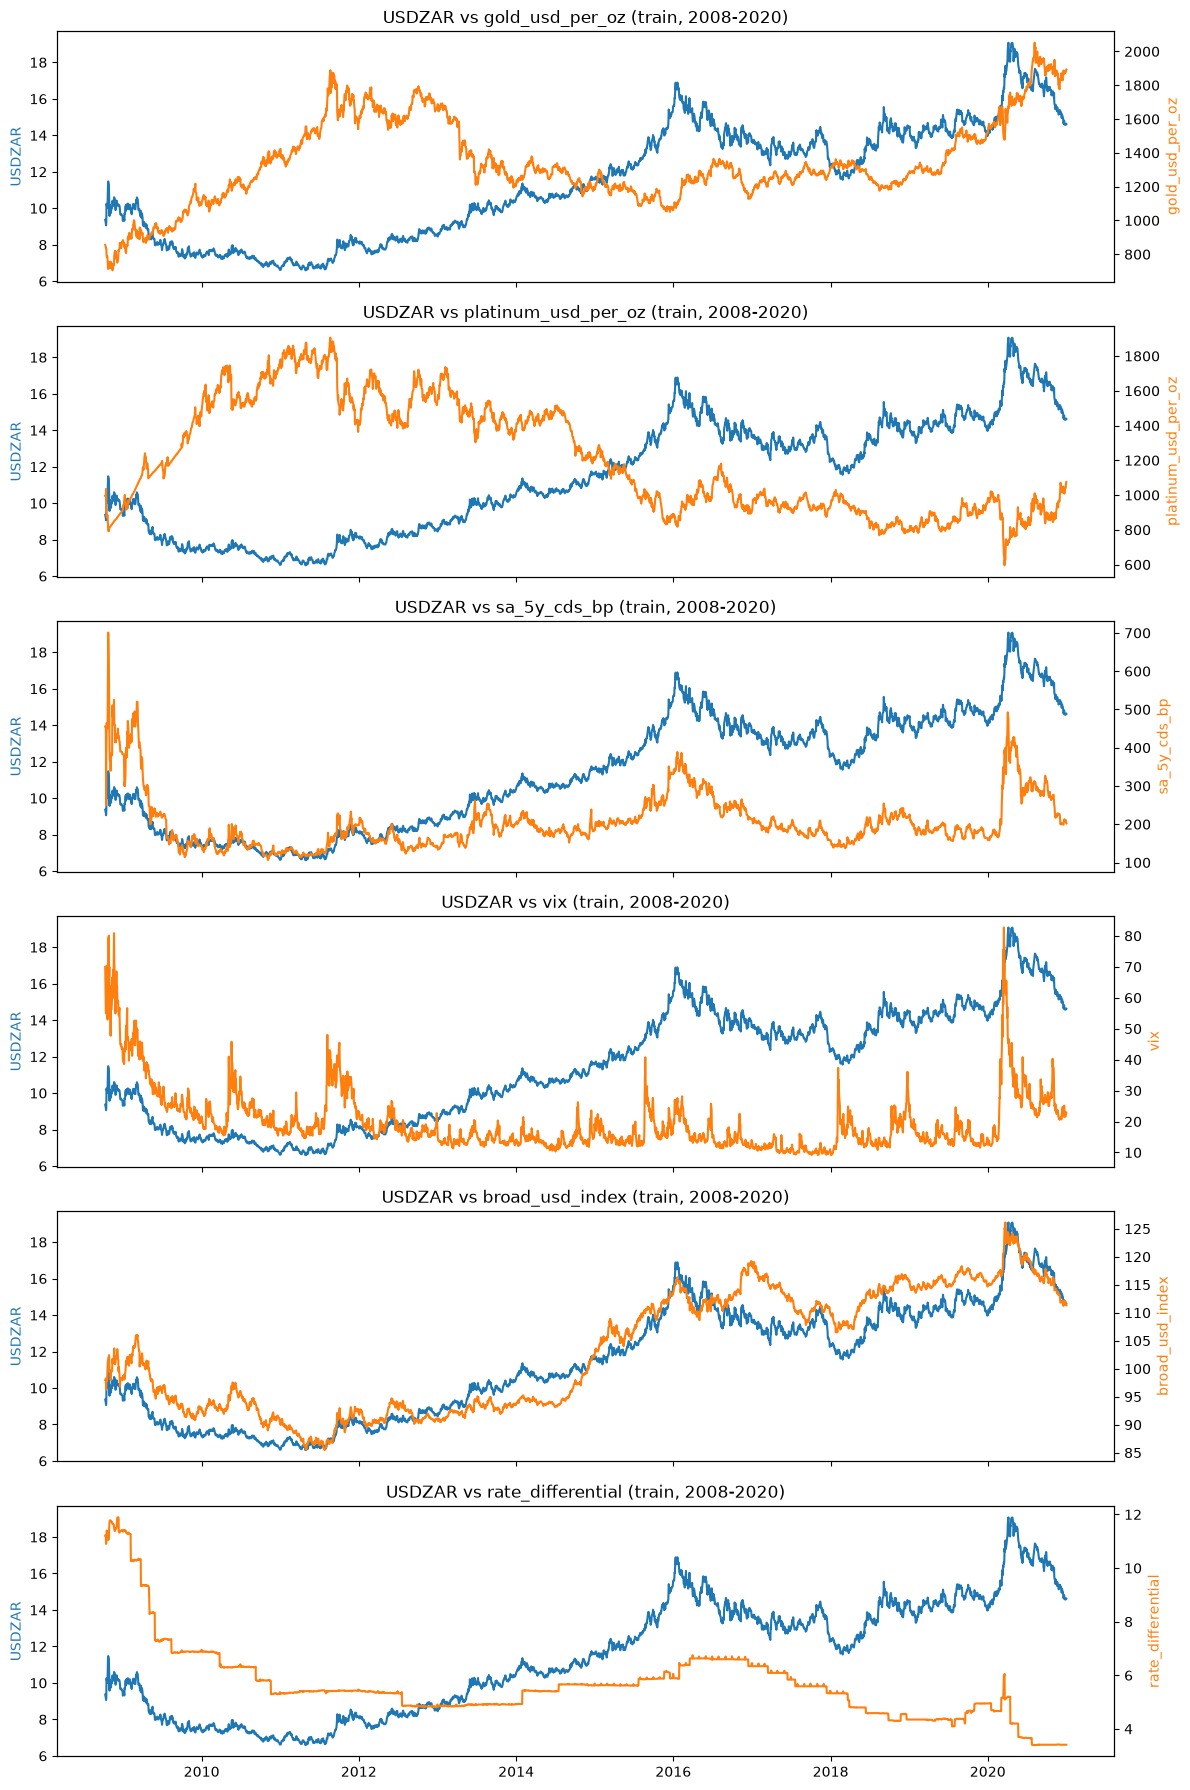

In [6]:
predictors = [c for c in key_cols if c != "usd_zar"]
fig, axes = plt.subplots(len(predictors), 1, figsize=(12, 3 * len(predictors)), sharex=True)

for ax, col in zip(axes, predictors):
    ax2 = ax.twinx()
    ax.plot(train["date"], train["usd_zar"], color="tab:blue")
    ax2.plot(train["date"], train[col], color="tab:orange")
    ax.set_ylabel("USDZAR", color="tab:blue")
    ax2.set_ylabel(col, color="tab:orange")
    ax.set_title(f"USDZAR vs {col} (train, 2008-2020)")

plt.tight_layout()
plt.show()

## USDZAR vs. each predictor over time — forecast period (2021–2025)

Same comparison restricted to 2021–2025, the actual out-of-sample window
used for the forecasting task.

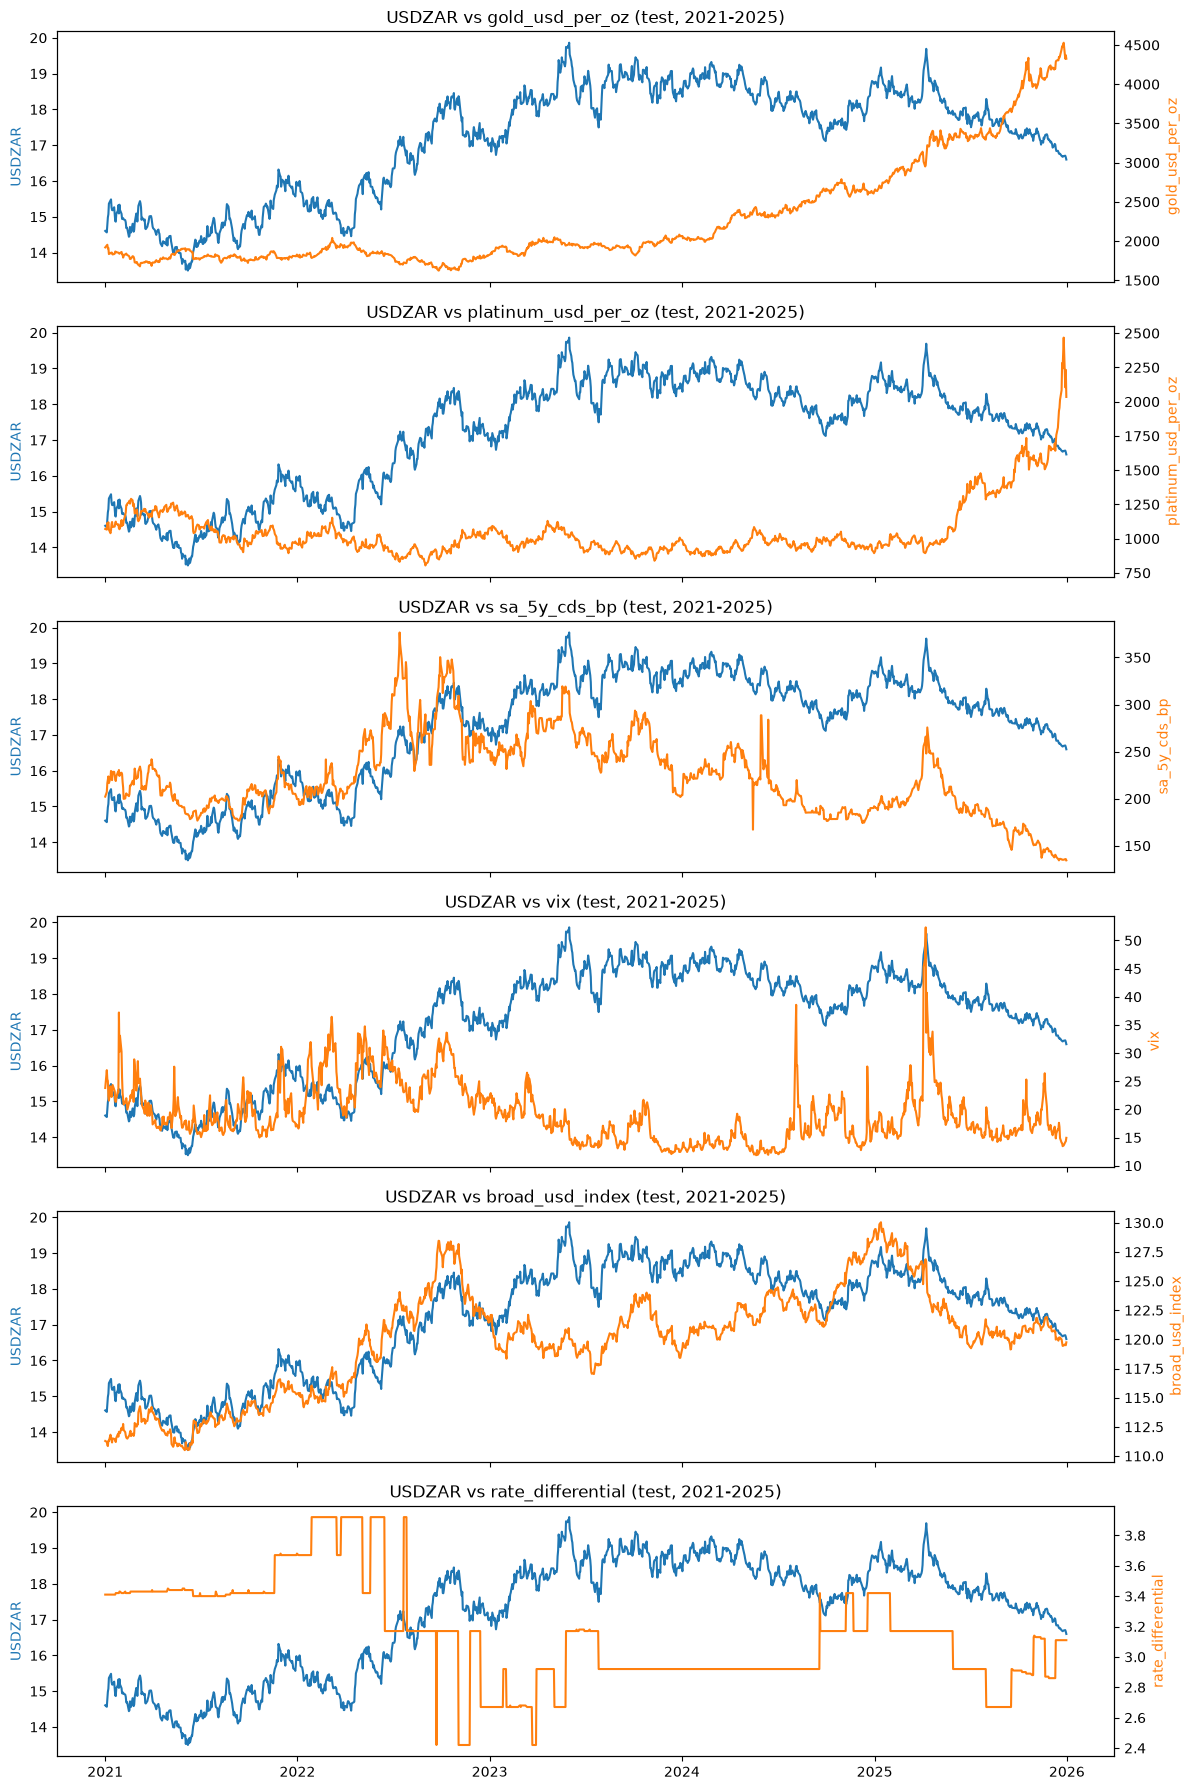

In [7]:
predictors = [c for c in key_cols if c != "usd_zar"]
fig, axes = plt.subplots(len(predictors), 1, figsize=(12, 3 * len(predictors)), sharex=True)

for ax, col in zip(axes, predictors):
    ax2 = ax.twinx()
    ax.plot(test["date"], test["usd_zar"], color="tab:blue")
    ax2.plot(test["date"], test[col], color="tab:orange")
    ax.set_ylabel("USDZAR", color="tab:blue")
    ax2.set_ylabel(col, color="tab:orange")
    ax.set_title(f"USDZAR vs {col} (test, 2021-2025)")

plt.tight_layout()
plt.show()

## Stationarity testing (ADF and KPSS)

Testing whether log(USDZAR) is stationary in levels or requires
differencing, using the Augmented Dickey-Fuller (ADF) and KPSS tests
on both the training and forecast periods.

In [8]:
from statsmodels.tsa.stattools import adfuller, kpss

log_train = np.log(train["usd_zar"])
log_test = np.log(test["usd_zar"])

for name, series in [("train levels", log_train), ("train diff", log_train.diff().dropna()),
                      ("test levels", log_test), ("test diff", log_test.diff().dropna())]:
    adf_stat, adf_p, *_ = adfuller(series)
    kpss_stat, kpss_p, *_ = kpss(series, nlags="auto")
    print(f"{name}: ADF p={adf_p:.4f} | KPSS p={kpss_p:.4f}")

train levels: ADF p=0.7972 | KPSS p=0.0100
train diff: ADF p=0.0000 | KPSS p=0.1000
test levels: ADF p=0.4663 | KPSS p=0.0100
test diff: ADF p=0.0000 | KPSS p=0.1000


C:\Users\neilh\AppData\Local\Temp\ipykernel_25684\1200817140.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(series, nlags="auto")
C:\Users\neilh\AppData\Local\Temp\ipykernel_25684\1200817140.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(series, nlags="auto")
C:\Users\neilh\AppData\Local\Temp\ipykernel_25684\1200817140.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(series, nlags="auto")
C:\Users\neilh\AppData\Local\Temp\ipykernel_25684\1200817140.py:9: InterpolationWarning: The test statistic is outside of the range of p-va